# Practice over Generation — full analysis notebook

Reproduces every statistic reported in "Practice over Generation:
AI-Authored Resources Rank Lowest in Engineering and Computer Science
Education" (IEEE Transactions on Education submission), including the
data underlying Figure 1.

**Self-contained**: the two anonymised, trimmed datasets (`POS` and
`PRE` questionnaire responses — IDs only, no names/emails; only the
Likert-item and section columns actually used in the analysis, no
free-text fields) are embedded directly in the next cell as CSV text,
so this notebook needs no external file to run. Raw free-text
responses (Q14/Q15), the pairing audit trail, and institutional grade
records are not included anywhere, to protect respondent
confidentiality (see the article's Data Availability Statement); the
"Academic outcomes" section at the end reports only the aggregate
percentages already published in the article, without recomputing
them from any file.

Every number below was checked against the manuscript at the time
this notebook was written and reproduces it exactly.


In [1]:
import io
import re
from collections import Counter

import numpy as np
import pandas as pd
import scikit_posthocs as sp
from scipy import stats

# Anonymised POST questionnaire responses (N=80): IDs, section, and every
# Likert/forced-choice item used in the analysis below (Q14/Q15 free-text
# excluded).
POS_CSV = """\
ID_Anonimo,Turma,Q01,Q02,Q03,Q04,Q05,Q06,Q07,Q08_01,Q08_02,Q08_03,Q08_04,Q08_05,Q08_06,Q08_07,Q08_08,Q08_09,Q08_10,Q08_11,Q09,Q10,Q11,Q12,Q13
Aluno_NA_POS_01,DA1,3,4,4,3,3,5,4,4,3,4,5,5,3,3,3,1,4,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,3,3
Aluno_POS_01,DA2,4,3,4,4,5,5,4,5,5,5,4,5,5,5,3,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,4,4
Aluno_POS_02,DA2,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,4,4,4
Aluno_NA_POS_02,DA2,5,1,1,2,3,4,3,2,1,2,4,4,3,4,3,4,4,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_06 - IA Feedback VPL] Feedback socrático por IA a cada submissão de código no VPL/Moodle, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",3,3,3,3
Aluno_POS_03,DA1,5,5,5,3,4,3,5,4,2,5,5,4,4,4,3,5,5,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",3,5,2,1
Aluno_NA_POS_03,DA1,5,3,3,5,4,2,4,5,3,5,4,5,5,5,5,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_06 - IA Feedback VPL] Feedback socrático por IA a cada submissão de código no VPL/Moodle",5,4,4,4
Aluno_NA_POS_04,DA2,5,3,3,2,2,2,2,4,1,3,5,2,3,3,3,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",3,2,3,3
Aluno_NA_POS_05,DA2,5,4,3,3,4,2,4,4,3,4,5,5,5,2,2,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,3,1,1
Aluno_NA_POS_06,DA2,5,5,3,2,2,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",5,5,5,5
Aluno_PAR_01,DA2,5,3,4,5,4,4,4,4,2,4,5,4,4,4,5,5,3,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_07 - IA Rubrica Provas] Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,2,3,4
Aluno_PAR_02,DA1,5,5,4,5,4,5,4,5,4,4,5,5,5,3,3,4,5,3,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,4,4
Aluno_PAR_03,DA2,5,4,3,4,4,3,4,3,2,4,5,5,4,2,4,4,4,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_07 - IA Rubrica Provas] Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,3,4
Aluno_POS_04,DA2,5,4,5,4,4,5,4,5,5,4,3,4,4,3,4,3,5,4,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,3,4,5
Aluno_NA_POS_07,DA1,5,2,2,3,3,2,3,2,1,3,5,3,3,2,2,4,3,3,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",3,3,2,3
Aluno_NA_POS_08,DA2,4,3,3,4,4,5,4,5,5,5,5,5,5,4,5,5,5,5,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",5,4,4,5
Aluno_NA_POS_09,DA1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",5,5,5,5
Aluno_NA_POS_10,DA1,5,3,3,4,5,2,4,5,3,5,5,5,4,2,3,5,4,1,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,3,4
Aluno_POS_05,MCC,5,5,5,4,5,2,5,4,4,5,2,4,3,2,2,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,2,4,4
Aluno_NA_POS_11,DA1,4,2,2,4,2,3,3,3,3,4,4,4,4,3,3,3,4,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,4,3
Aluno_NA_POS_12,DA1,4,4,4,4,4,4,4,4,1,4,4,4,4,3,1,4,4,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",3,1,1,1
Aluno_NA_POS_13,DA1,3,3,4,2,3,3,3,4,3,4,4,4,2,2,3,2,3,2,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",3,3,4,3
Aluno_NA_POS_14,DA1,5,4,4,4,3,2,5,4,4,5,5,5,4,2,4,2,5,3,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,4,4
Aluno_PAR_04,DA1,5,5,4,3,4,5,5,5,5,5,5,5,5,5,5,4,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,5,5,5
Aluno_PAR_05,MCC,4,5,5,4,4,3,5,5,3,5,4,3,4,3,3,4,5,2,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,2,2,5
Aluno_POS_06,DA1,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_07 - IA Rubrica Provas] Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,4,4,4
Aluno_NA_POS_15,DA1,5,4,4,4,5,3,5,5,3,5,5,5,4,3,4,5,5,4,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,4,4
Aluno_NA_POS_16,DA2,4,4,3,3,5,4,4,4,5,5,5,5,4,4,4,5,4,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,5,4,4
Aluno_POS_07,MCC,5,4,5,3,4,2,5,5,3,5,5,5,4,1,4,2,3,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",4,3,3,4
Aluno_PAR_06,MCC,5,4,5,2,4,5,5,5,5,5,5,5,5,5,5,5,5,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,5,4,5
Aluno_PAR_07,DA1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_06 - IA Feedback VPL] Feedback socrático por IA a cada submissão de código no VPL/Moodle, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",5,5,5,5
Aluno_NA_POS_17,DA2,5,5,5,4,5,5,5,5,4,5,5,5,5,4,4,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,5,5,5
Aluno_PAR_08,DA1,4,4,4,2,4,4,4,3,2,5,5,5,3,4,4,3,4,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_07 - IA Rubrica Provas] Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",3,5,4,4
Aluno_POS_08,DA2,5,3,4,5,3,3,5,5,2,5,5,4,2,3,3,5,2,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,2,3,3
Aluno_NA_POS_18,DA2,3,3,3,3,4,1,4,4,1,3,5,2,1,1,1,5,5,4,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",3,1,1,1
Aluno_NA_POS_19,DA2,5,4,3,4,3,3,5,5,4,5,5,4,4,2,4,4,3,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,4,3,3
Aluno_PAR_09,DA2,5,4,4,3,4,2,4,5,4,5,5,2,5,3,3,3,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,2,5,5
Aluno_NA_POS_20,DA2,5,4,4,3,5,5,5,5,4,5,5,5,5,4,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",4,4,4,5
Aluno_NA_POS_21,DA1,5,4,4,3,4,4,4,4,5,5,5,5,5,4,3,4,3,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",5,3,3,4
Aluno_NA_POS_22,DA1,4,4,3,4,5,5,4,3,3,5,5,5,5,5,3,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_06 - IA Feedback VPL] Feedback socrático por IA a cada submissão de código no VPL/Moodle, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,4,3,3
Aluno_NA_POS_23,DA2,5,3,3,4,4,3,5,4,2,4,4,5,5,3,3,2,3,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,3,3
Aluno_NA_POS_24,DA1,1,2,1,1,1,1,2,4,1,5,4,4,5,1,3,3,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",3,1,1,1
Aluno_POS_09,MCC,4,5,3,4,4,4,5,5,3,5,5,5,4,3,5,5,3,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,4,5,5
Aluno_POS_10,DA1,4,2,3,4,3,5,3,4,2,4,5,5,5,4,5,5,4,3,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_06 - IA Feedback VPL] Feedback socrático por IA a cada submissão de código no VPL/Moodle, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,4,4
Aluno_PAR_10,DA1,2,3,3,1,3,2,3,4,4,4,4,4,4,4,4,4,4,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,5,4,5
Aluno_NA_POS_25,DA1,5,3,3,3,4,4,4,5,1,4,5,5,4,4,3,3,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,3,4,4
Aluno_PAR_11,DA1,5,3,4,4,4,3,4,4,3,5,5,5,5,4,4,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,4,4,4
Aluno_POS_11,DA1,5,3,5,4,4,4,4,5,3,4,5,5,5,5,5,5,5,3,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",4,4,5,4
Aluno_NA_POS_26,DA1,5,3,2,3,3,2,5,4,3,4,5,4,5,3,3,5,5,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,3,4,3
Aluno_POS_12,DA1,4,2,2,4,2,4,1,3,1,4,5,5,1,2,3,4,4,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",2,2,1,1
Aluno_NA_POS_27,DA1,5,4,4,2,3,1,4,5,2,4,4,5,5,1,3,4,5,5,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",3,2,2,2
Aluno_POS_13,DA2,5,3,4,4,4,3,4,5,3,4,3,4,4,3,4,4,4,4,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,4,4,4
Aluno_POS_14,DA2,5,4,5,3,2,4,4,5,4,5,5,5,4,4,5,5,3,3,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",5,5,4,5
Aluno_NA_POS_28,DA1,5,5,5,3,5,4,5,5,3,5,3,3,2,3,3,4,3,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",5,3,3,3
Aluno_NA_POS_29,DA1,5,5,3,3,3,1,3,3,1,3,5,3,5,5,3,3,3,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,5,1,3
Aluno_NA_POS_30,DA2,5,4,4,4,4,3,5,4,4,5,5,4,4,3,3,5,4,5,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab",5,4,5,5
Aluno_POS_15,DA2,4,4,5,3,4,4,5,5,4,5,4,5,4,2,3,2,5,3,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",5,4,4,4
Aluno_NA_POS_31,DA2,5,4,2,5,4,2,5,5,3,5,5,5,5,5,5,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,3,4,5
Aluno_NA_POS_32,DA1,5,2,4,1,4,1,4,4,2,4,5,2,3,1,1,4,1,4,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",3,3,1,1
Aluno_NA_POS_33,DA1,5,3,3,5,2,4,2,2,1,3,3,3,1,3,3,4,3,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",2,3,3,3
Aluno_POS_16,DA2,5,3,4,3,2,1,3,5,1,5,5,5,5,2,3,3,3,4,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",4,2,3,2
Aluno_NA_POS_34,MCC,5,4,5,4,5,4,5,5,3,5,5,5,4,4,3,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",5,3,4,4
Aluno_NA_POS_35,DA1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",3,3,3,3
Aluno_NA_POS_36,DA1,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab",3,3,4,3
Aluno_POS_17,DA1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",3,5,5,5
Aluno_NA_POS_37,DA1,5,3,3,5,4,5,4,5,3,5,5,5,5,4,3,5,5,3,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,3,4,4
Aluno_PAR_12,MCC,4,3,5,4,4,5,5,4,4,5,4,5,4,5,4,5,4,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,4,5,5
Aluno_POS_18,DA2,4,4,4,4,4,4,4,5,2,4,5,5,5,4,4,5,5,5,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,4,4,4
Aluno_POS_19,DA2,5,5,4,3,4,5,5,5,4,4,4,4,4,4,4,5,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_07 - IA Rubrica Provas] Feedback por e-mail com rubrica de avaliação qualitativa gerada por IA nos Simulados/Provas, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,4,4,4
Aluno_NA_POS_38,DA2,5,1,1,3,3,4,3,4,2,3,4,4,3,3,3,3,3,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,3,3,3
Aluno_NA_POS_39,DA2,4,4,3,4,5,3,4,4,4,3,5,5,4,4,3,5,3,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",3,3,4,4
Aluno_POS_20,DA2,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,"[Q09_01 - Gemini Audio/Visual] Material didático audiovisual gerado por IA (Vídeos e Slides do Gemini Notebook), [Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_05 - morph.py] Biblioteca didática morph.py",5,4,4,4
Aluno_NA_POS_40,DA2,5,2,3,5,3,1,3,3,1,5,4,1,3,1,3,5,2,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",2,3,2,2
Aluno_NA_POS_41,MCC,4,3,4,4,3,4,4,4,3,4,4,4,4,4,4,4,4,3,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB)",4,4,4,4
Aluno_PAR_13,MCC,5,3,4,3,4,1,3,4,1,1,5,1,1,1,1,2,5,5,"[Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,1,1,1
Aluno_PAR_14,MCC,5,5,5,2,4,4,5,5,4,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,4,5,5
Aluno_POS_21,MCC,5,5,5,5,5,1,3,3,1,2,5,1,5,3,1,3,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,1,1,1
Aluno_NA_POS_42,DA1,5,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",5,5,5,5
Aluno_POS_22,DA1,5,5,5,3,4,5,5,5,5,5,5,5,5,5,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_03 - EPs em Aula] Resolução dos Exercícios de Programação (EPs) em sala de aula, [Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py",5,5,5,5
Aluno_PAR_15,DA1,5,4,4,2,5,3,4,4,1,4,5,5,5,3,3,5,5,5,"[Q09_04 - Livro Interativo] Livro interativo no formato HTML / Colab, [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_09 - VPL Casos Teste] Validação objetiva por casos de teste no VPL",4,5,5,4
Aluno_NA_POS_43,DA1,3,4,2,2,4,3,5,3,4,5,4,5,3,1,5,5,5,5,"[Q09_02 - Simuladores] Simuladores interativos (manipulação de parâmetros), [Q09_05 - morph.py] Biblioteca didática morph.py, [Q09_08 - SEB Simulados] Simulados quinzenais em laboratório (SEB), [Q09_10 - TestSuite.py] Uso do testsuite.py no Colab para testar EPs localmente",4,2,2,3
"""

# Anonymised PRE questionnaire responses (N=104): IDs and the six matched
# self-perception items only (demographic/free-text fields excluded).
PRE_CSV = """\
ID_Anonimo,PRE_Q01,PRE_Q02,PRE_Q03,PRE_Q04,PRE_Q05,PRE_Q06
Aluno_PAR_08,4,3,5,5,3,4
Aluno_NA_PRE_01,5,3,3,3,4,4
Aluno_PAR_01,5,5,3,3,5,4
Aluno_PAR_04,5,5,3,3,4,5
Aluno_NA_PRE_02,5,2,5,5,3,4
Aluno_PAR_11,5,4,5,5,3,3
Aluno_PAR_10,5,5,5,5,4,5
Aluno_NA_PRE_03,4,5,5,5,3,3
Aluno_NA_PRE_04,4,3,4,5,2,1
Aluno_NA_PRE_05,5,5,5,5,3,4
Aluno_NA_PRE_06,4,4,4,4,4,4
Aluno_NA_PRE_07,4,4,4,5,4,5
Aluno_NA_PRE_08,4,3,5,5,4,4
Aluno_NA_PRE_09,5,4,5,5,5,1
Aluno_NA_PRE_10,5,5,4,5,3,3
Aluno_NA_PRE_11,5,5,5,5,4,5
Aluno_PRE_01,5,4,5,5,3,4
Aluno_NA_PRE_12,5,4,5,5,2,4
Aluno_PRE_02,5,5,5,5,4,5
Aluno_PRE_03,4,4,5,4,3,5
Aluno_NA_PRE_13,5,3,4,5,4,5
Aluno_NA_PRE_14,5,1,5,5,2,4
Aluno_NA_PRE_15,5,5,5,5,4,5
Aluno_PAR_12,4,4,5,5,4,2
Aluno_NA_PRE_16,3,4,4,4,3,2
Aluno_PRE_04,5,5,5,5,3,5
Aluno_PRE_05,2,5,5,5,2,1
Aluno_PAR_07,5,5,5,5,5,5
Aluno_NA_PRE_17,5,5,4,2,4,5
Aluno_NA_PRE_18,5,4,4,4,3,3
Aluno_PAR_06,5,5,4,5,1,2
Aluno_PRE_06,5,2,5,5,4,5
Aluno_NA_PRE_19,3,1,4,4,3,4
Aluno_PAR_13,5,2,5,5,3,5
Aluno_NA_PRE_20,5,2,5,5,4,5
Aluno_PAR_14,4,3,5,5,1,4
Aluno_NA_PRE_21,4,3,3,3,2,2
Aluno_NA_PRE_22,4,4,3,3,4,4
Aluno_PRE_07,5,5,5,5,4,5
Aluno_PRE_08,5,5,5,5,4,5
Aluno_PRE_09,3,4,5,4,2,1
Aluno_NA_PRE_23,4,4,4,4,3,4
Aluno_NA_PRE_24,5,4,5,5,3,4
Aluno_PRE_10,5,4,4,4,4,5
Aluno_NA_PRE_25,4,4,4,4,3,4
Aluno_PRE_11,5,3,5,5,5,5
Aluno_PAR_03,5,4,4,4,5,5
Aluno_NA_PRE_26,5,5,5,3,2,4
Aluno_PRE_12,5,5,4,5,4,4
Aluno_NA_PRE_27,5,5,4,3,4,4
Aluno_PAR_02,5,5,5,5,5,4
Aluno_NA_PRE_28,5,5,5,3,3,4
Aluno_NA_PRE_29,5,4,5,5,4,4
Aluno_NA_PRE_30,5,5,3,3,2,4
Aluno_PRE_13,5,3,5,4,5,5
Aluno_NA_PRE_31,5,5,4,5,2,4
Aluno_NA_PRE_32,5,4,4,5,3,4
Aluno_NA_PRE_33,4,5,5,5,3,4
Aluno_NA_PRE_34,4,3,3,4,3,1
Aluno_PRE_14,5,3,4,4,2,5
Aluno_NA_PRE_35,4,5,3,3,1,4
Aluno_NA_PRE_36,5,5,5,3,4,5
Aluno_NA_PRE_37,5,5,5,5,4,5
Aluno_NA_PRE_38,4,4,3,3,2,2
Aluno_NA_PRE_39,5,4,5,5,2,5
Aluno_NA_PRE_40,4,4,4,4,1,2
Aluno_PRE_15,3,2,3,2,2,2
Aluno_NA_PRE_41,5,5,5,5,3,5
Aluno_NA_PRE_42,4,4,5,5,1,2
Aluno_NA_PRE_43,4,3,3,3,2,2
Aluno_NA_PRE_44,3,3,3,3,2,2
Aluno_NA_PRE_45,4,3,4,4,2,4
Aluno_PRE_16,5,5,5,5,1,1
Aluno_NA_PRE_46,5,5,4,4,2,2
Aluno_NA_PRE_47,5,5,5,5,5,5
Aluno_NA_PRE_48,5,5,5,5,4,5
Aluno_PAR_15,5,5,5,5,4,5
Aluno_PRE_17,4,4,5,5,4,3
Aluno_NA_PRE_49,5,5,5,5,4,4
Aluno_PRE_18,4,4,4,5,4,2
Aluno_PRE_19,5,5,5,5,5,5
Aluno_PRE_20,5,4,5,5,2,3
Aluno_PRE_21,4,4,4,4,4,2
Aluno_NA_PRE_50,5,5,3,3,2,2
Aluno_PRE_22,1,2,3,3,1,1
Aluno_PAR_05,4,4,5,5,4,4
Aluno_PRE_23,5,3,4,4,5,5
Aluno_NA_PRE_51,4,4,5,5,3,4
Aluno_NA_PRE_52,5,3,3,3,4,4
Aluno_NA_PRE_53,5,3,4,5,3,2
Aluno_NA_PRE_54,5,4,4,4,2,3
Aluno_NA_PRE_55,4,4,4,4,4,4
Aluno_NA_PRE_56,4,4,3,4,4,4
Aluno_NA_PRE_57,5,3,5,5,5,5
Aluno_PRE_24,3,2,5,5,4,2
Aluno_PAR_09,5,4,5,5,3,5
Aluno_NA_PRE_58,4,4,5,4,3,3
Aluno_NA_PRE_59,3,4,4,3,2,2
Aluno_NA_PRE_60,5,4,4,4,3,2
Aluno_NA_PRE_61,4,4,5,5,3,4
Aluno_NA_PRE_62,4,4,5,5,3,2
Aluno_PRE_25,4,3,4,4,4,3
Aluno_PRE_26,5,5,5,5,2,5
Aluno_PRE_27,4,4,4,4,4,4
"""

pos = pd.read_csv(io.StringIO(POS_CSV))
pre = pd.read_csv(io.StringIO(PRE_CSV))

print("POST respondents:", len(pos), " PRE respondents:", len(pre))


POST respondents: 80  PRE respondents: 104


## 1. The ten Block-3 resources: classification, ranking, and reliability

Resources are classified *a priori* by the role AI played in their
production (Section III-E of the article), independently of the
survey results.


In [2]:
BLOCK3 = [f"Q08_{i:02d}" for i in range(1, 11)]

LABEL = {
    "Q08_01": "Interactive book",
    "Q08_02": "AI-generated instructional material",
    "Q08_03": "Interactive simulators",
    "Q08_04": "In-class exercise resolution",
    "Q08_05": "morph.py library",
    "Q08_06": "Parameterised exams/quizzes",
    "Q08_07": "Socratic AI feedback (VPL)",
    "Q08_08": "AI-generated grading rubric",
    "Q08_09": "Objective VPL grading",
    "Q08_10": "Objective TestSuite.py grading",
}

ROLE = {
    "Q08_04": "none", "Q08_09": "none", "Q08_10": "none",
    "Q08_01": "aid", "Q08_03": "aid", "Q08_05": "aid", "Q08_06": "aid",
    "Q08_02": "direct", "Q08_07": "direct", "Q08_08": "direct",
}

VALOR_NEUTRO = 3.0


def rank_biserial(diffs_nz):
    """Exact rank-biserial correlation (Wpos - Wneg) / total, matching the
    convention used throughout the article -- not the z/sqrt(n) approximation."""
    n = len(diffs_nz)
    ranks = stats.rankdata(diffs_nz.abs())
    total = n * (n + 1) / 2
    wpos = ranks[(diffs_nz > 0).values].sum()
    wneg = ranks[(diffs_nz < 0).values].sum()
    return (wpos - wneg) / total


In [3]:
rows = []
for cod in BLOCK3:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    diffs = serie - VALOR_NEUTRO
    diffs_nz = diffs[diffs != 0]
    _, p = stats.wilcoxon(diffs_nz)
    r = rank_biserial(diffs_nz)
    rows.append({
        "Item & resource": f"{cod}. {LABEL[cod]}", "AI role": ROLE[cod],
        "M": round(serie.mean(), 3), "SD": round(serie.std(ddof=1), 3),
        "Mdn": serie.median(), "r": round(r, 3),
        "p vs. 3.0": "<.001" if p < .001 else f"{p:.3f}".lstrip("0"),
    })

ranking = pd.DataFrame(rows).sort_values("M", ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.index.name = "Rank"
ranking


,Item & resource,AI role,M,SD,Mdn,r,p vs. 3.0
Rank,,,,,,,
1,Q08_04. In-class exercise resolution,none,4.588,0.650,5.0,0.992,<.001
2,Q08_03. Interactive simulators,aid,4.362,0.846,5.0,0.940,<.001
3,Q08_05. morph.py library,aid,4.300,1.048,5.0,0.855,<.001
4,Q08_01. Interactive book,aid,4.288,0.814,4.0,0.960,<.001
5,Q08_10. Objective TestSuite.py grading,none,4.262,0.938,5.0,0.939,<.001
6,Q08_09. Objective VPL grading,none,4.212,1.015,5.0,0.893,<.001
7,Q08_06. Parameterised exams/quizzes,aid,4.075,1.077,4.0,0.794,<.001
8,Q08_08. AI-generated grading rubric,direct,3.588,1.099,3.5,0.633,<.001
9,Q08_07. Socratic AI feedback (VPL),direct,3.388,1.248,4.0,0.364,.011


In [4]:
data = pos[BLOCK3].dropna()
chi2, p = stats.friedmanchisquare(*[data[c] for c in BLOCK3])
n, k = data.shape
W = chi2 / (n * (k - 1))
print(f"Friedman: chi2({k - 1}) = {chi2:.2f}, p = {p:.3g}  (N = {n})")
print(f"Kendall's W = {W:.3f}")


Friedman: chi2(9) = 189.66, p = 4.85e-36  (N = 80)
Kendall's W = 0.263


## 2. Post-hoc pairwise comparisons (Conover, Bonferroni-corrected)

45 pairwise comparisons among the ten resources ($\binom{10}{2}$),
following the significant Friedman test above.


In [5]:
posthoc = sp.posthoc_conover_friedman(data, p_adjust="bonferroni")

target = "Q08_02"  # AI-generated instructional material, the lowest-rated resource
sig_vs_target = posthoc[target].drop(index=target)
n_sig = (sig_vs_target < .05).sum()
print(f"{LABEL[target]} differs significantly (p < .05, Bonferroni) from "
      f"{n_sig} of the other {len(sig_vs_target)} resources:")
sig_vs_target.map(lambda p: f"{p:.4f}").to_frame("p (Bonferroni)")


AI-generated instructional material differs significantly (p < .05, Bonferroni) from 7 of the other 9 resources:


,p (Bonferroni)
Q08_01,0.0000
Q08_03,0.0000
Q08_04,0.0000
Q08_05,0.0000
Q08_06,0.0000
Q08_07,1.0000
Q08_08,0.0919
Q08_09,0.0000
Q08_10,0.0000


## 3. Aggregate declared-preference ranking (Q09)

Q09 is a forced-choice item (select up to 4 of the ten resources),
not a Likert item; counted by selection frequency across all 80
respondents.


In [6]:
Q09_TO_Q08 = {
    "Q09_01": "Q08_02", "Q09_02": "Q08_03", "Q09_03": "Q08_04", "Q09_04": "Q08_01",
    "Q09_05": "Q08_05", "Q09_06": "Q08_07", "Q09_07": "Q08_08", "Q09_08": "Q08_06",
    "Q09_09": "Q08_09", "Q09_10": "Q08_10",
}

q09 = pos["Q09"].dropna()
counts = Counter()
for val in q09:
    for code_ in re.findall(r"Q09_(\d{2})", val):
        counts["Q09_" + code_] += 1

pref = pd.DataFrame([
    {"Item & resource": f"{Q09_TO_Q08[k]}. {LABEL[Q09_TO_Q08[k]]}",
     "AI role": ROLE[Q09_TO_Q08[k]], "Choices": v, "%": f"{100 * v / len(q09):.1f}%"}
    for k, v in counts.items()
]).sort_values("Choices", ascending=False).reset_index(drop=True)

print(f"N = {len(q09)} students, 4 choices each, {sum(counts.values())} selections in total")
pref


N = 80 students, 4 choices each, 320 selections in total


,Item & resource,AI role,Choices,%
0,Q08_04. In-class exercise resolution,none,62,77.5%
1,Q08_05. morph.py library,aid,59,73.8%
2,Q08_03. Interactive simulators,aid,45,56.2%
3,Q08_01. Interactive book,aid,43,53.8%
4,Q08_06. Parameterised exams/quizzes,aid,41,51.2%
5,Q08_10. Objective TestSuite.py grading,none,33,41.2%
6,Q08_09. Objective VPL grading,none,21,26.2%
7,Q08_02. AI-generated instructional material,direct,6,7.5%
8,Q08_07. Socratic AI feedback (VPL),direct,5,6.2%
9,Q08_08. AI-generated grading rubric,direct,5,6.2%


## 4. Reliability and convergent validity

Cronbach's alpha for Block 3 (the ten resources) and for the two
AI-transversality items (Q11, Q12); Spearman correlations between
each set and its block's global rating.


In [7]:
def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alpha_block3 = cronbach_alpha(pos[BLOCK3])
alpha_ai = cronbach_alpha(pos[["Q11", "Q12"]])
print(f"Block 3 (10 items): alpha = {alpha_block3:.3f}  (n = {pos[BLOCK3].dropna().shape[0]})")
print(f"AI-transversality (Q11, Q12): alpha = {alpha_ai:.3f}  (n = {pos[['Q11', 'Q12']].dropna().shape[0]})")

rho1, p1 = stats.spearmanr(pos[BLOCK3].mean(axis=1), pos["Q10"])
rho2, p2 = stats.spearmanr(pos[["Q11", "Q12"]].mean(axis=1), pos["Q13"])
print(f"Block 3 mean vs. Q10 (global rating): rho = {rho1:.3f}, p = {p1:.3g}, "
      f"M_Q10 = {pos['Q10'].mean():.3f}, Mdn = {pos['Q10'].median():.0f}")
print(f"Q11+Q12 mean vs. Q13 (global AI-integration item): rho = {rho2:.3f}, p = {p2:.3g}")


Block 3 (10 items): alpha = 0.842  (n = 80)
AI-transversality (Q11, Q12): alpha = 0.786  (n = 80)
Block 3 mean vs. Q10 (global rating): rho = 0.519, p = 8e-07, M_Q10 = 4.075, Mdn = 4
Q11+Q12 mean vs. Q13 (global AI-integration item): rho = 0.777, p = 2.24e-17


## 5. Between-section differences (Kruskal–Wallis)

Checks whether the global ratings Q10 (Block 3) and Q13 (Block 4)
differ across the course's three sections (`Turma`).


In [8]:
for col in ["Q10", "Q13"]:
    groups = [g[col].dropna().values for _, g in pos.groupby("Turma")]
    H, p = stats.kruskal(*groups)
    print(f"{col}: H = {H:.2f}, p = {p:.3f}")


Q10: H = 4.71, p = 0.095
Q13: H = 3.38, p = 0.184


## 6. PRE/POST comparison across six self-perception dimensions

**Item numbering shifts between the PRE and POST questionnaires** —
confirmed against `metadados_perguntas.json`'s extracted item labels,
not just position: `PRE_Q02` (AI feedback) corresponds to POST `Q06`,
`PRE_Q03` (Academic relevance) to `Q02`, `PRE_Q04` (Professional
relevance) to `Q03`, `PRE_Q05` (Mathematical foundations) to `Q04`,
and `PRE_Q06` (Library autonomy) to `Q05`; only `PRE_Q01` /
`Q01` (Programming ability) share the same number.

The article's paired-comparison table reports the **full-sample**
descriptive statistics (mean, median; $N_\mathrm{pre}=104$,
$N_\mathrm{post}=80$) side by side with the **matched-pairs**
inferential test (Wilcoxon signed-rank on the 15 respondents who
answered both PRE and POST) — both are reproduced below.


In [9]:
DIMENSIONS = {
    "Programming ability": ("PRE_Q01", "Q01"),
    "Academic relevance": ("PRE_Q03", "Q02"),
    "Professional relevance": ("PRE_Q04", "Q03"),
    "Mathematical foundations": ("PRE_Q05", "Q04"),
    "Library autonomy": ("PRE_Q06", "Q05"),
    "AI feedback": ("PRE_Q02", "Q06"),
}

par_pre = pre[pre["ID_Anonimo"].str.startswith("Aluno_PAR_")]
par_pos = pos[pos["ID_Anonimo"].str.startswith("Aluno_PAR_")]
matched = par_pre.merge(par_pos, on="ID_Anonimo", suffixes=("_pre", "_pos"))
print(f"Matched PRE/POST respondents: N = {len(matched)}")


Matched PRE/POST respondents: N = 15


In [10]:
paired_rows = []
for name, (prec, posc) in DIMENSIONS.items():
    full_pre = pd.to_numeric(pre[prec], errors="coerce").dropna()
    full_pos = pd.to_numeric(pos[posc], errors="coerce").dropna()

    a = pd.to_numeric(matched[prec], errors="coerce")
    b = pd.to_numeric(matched[posc], errors="coerce")
    d = (b - a).dropna()
    _, p = stats.wilcoxon(d)
    r = rank_biserial(d)

    paired_rows.append({
        "Dimension": name,
        "M_pre (full, N=104)": round(full_pre.mean(), 3),
        "M_post (full, N=80)": round(full_pos.mean(), 3),
        "Mdn_pre": full_pre.median(), "Mdn_post": full_pos.median(),
        "r (matched, n=15)": round(r, 3),
        "p (Wilcoxon)": round(p, 3),
    })

pd.DataFrame(paired_rows)


,Dimension,"M_pre (full, N=104)","M_post (full, N=80)",Mdn_pre,Mdn_post,"r (matched, n=15)",p (Wilcoxon)
0,Programming ability,4.481,4.562,5.0,5.0,-0.008,0.655
1,Academic relevance,4.385,3.712,5.0,4.0,-0.550,0.083
2,Professional relevance,4.356,3.725,5.0,4.0,-0.542,0.052
3,Mathematical foundations,3.212,3.538,3.0,4.0,-0.242,0.272
4,Library autonomy,3.663,3.825,4.0,4.0,-0.133,0.885
5,AI feedback,3.981,3.438,4.0,4.0,-0.492,0.070


Unpaired comparison on the full PRE/POST samples (Mann–Whitney *U*, Cohen's *d*):

In [11]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp_ = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (b.mean() - a.mean()) / sp_


unpaired_rows = []
for name, (prec, posc) in DIMENSIONS.items():
    a = pd.to_numeric(pre[prec], errors="coerce").dropna()
    b = pd.to_numeric(pos[posc], errors="coerce").dropna()
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    d = cohens_d(a, b)
    unpaired_rows.append({
        "Dimension": name, "M_pre": round(a.mean(), 3), "M_post": round(b.mean(), 3),
        "Cohen's d": round(d, 3),
        "p": "<.001" if p < .001 else f"{p:.3f}",
    })

pd.DataFrame(unpaired_rows).sort_values("p")


,Dimension,M_pre,M_post,Cohen's d,p
5,AI feedback,3.981,3.438,-0.471,0.008
3,Mathematical foundations,3.212,3.538,0.303,0.048
0,Programming ability,4.481,4.562,0.108,0.301
4,Library autonomy,3.663,3.825,0.142,0.865
1,Academic relevance,4.385,3.712,-0.775,<.001
2,Professional relevance,4.356,3.725,-0.677,<.001


## 7. Figure 1 — distribution of the 21 Likert items

Ranking (by mean) and one-sample Wilcoxon test against the neutral
scale midpoint (3.0) for all 21 Likert items across Blocks 2, 3, and
4 — not just the ten Block-3 resources. This is the same computation
and figure published as Figure 1 of the article (`gen_fig01.py` in
the article's own repository generates the identical PDF from this
same logic).


In [12]:
import matplotlib
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

CODES = ["Q01", "Q02", "Q03", "Q04", "Q05", "Q06", "Q07"] + BLOCK3 + ["Q10", "Q11", "Q12", "Q13"]
assert len(CODES) == 21

LABELS_21 = {
    "Q01": "Programming ability (POST)", "Q02": "Academic relevance (POST)",
    "Q03": "Professional relevance (POST)", "Q04": "Mathematical foundations (POST)",
    "Q05": "Library autonomy (POST)", "Q06": "AI feedback (POST)",
    "Q07": "Global rating -- Block 2 (learning)",
    **LABEL,
    "Q10": "Global rating -- Block 3 (resources)",
    "Q11": "Critical thinking and hallucinations",
    "Q12": "Pedagogical transversality",
    "Q13": "Global rating -- Block 4 (AI integration)",
}
ROLE_21 = dict(ROLE)
for c in CODES:
    ROLE_21.setdefault(c, "unclassified")


def format_p(p):
    if pd.isna(p):
        return "--"
    if p < 0.001:
        return "<.001"
    return f"{p:.3f}".lstrip("0")


rows21 = []
for cod in CODES:
    serie = pd.to_numeric(pos[cod], errors="coerce").dropna()
    diffs = serie - VALOR_NEUTRO
    diffs_nz = diffs[diffs != 0]
    _, p = stats.wilcoxon(diffs_nz)
    r = rank_biserial(diffs_nz)
    rows21.append({"item": cod, "label": f"{cod}. {LABELS_21[cod]}", "role": ROLE_21[cod],
                    "mean": serie.mean(), "p": p, "r": r})

df21 = pd.DataFrame(rows21).sort_values("mean", ascending=False).reset_index(drop=True)
df21[["label", "mean", "r", "p"]]


,label,mean,r,p
0,Q08_04. In-class exercise resolution,4.5875,0.991798,3.418430e-15
1,Q01. Programming ability (POST),4.5625,0.958988,2.034676e-14
2,Q08_03. Interactive simulators,4.3625,0.939652,4.826585e-13
3,Q08_05. morph.py library,4.3000,0.854737,2.082593e-11
4,Q08_01. Interactive book,4.2875,0.960094,3.888512e-13
5,Q08_10. Objective TestSuite.py grading,4.2625,0.938928,6.169371e-12
6,Q08_09. Objective VPL grading,4.2125,0.892958,1.633226e-11
7,Q07. Global rating -- Block 2 (learning),4.1250,0.907928,1.840168e-11
8,Q08_06. Parameterised exams/quizzes,4.0750,0.794366,2.439231e-09
9,Q10. Global rating -- Block 3 (resources),4.0750,0.945455,7.004812e-12


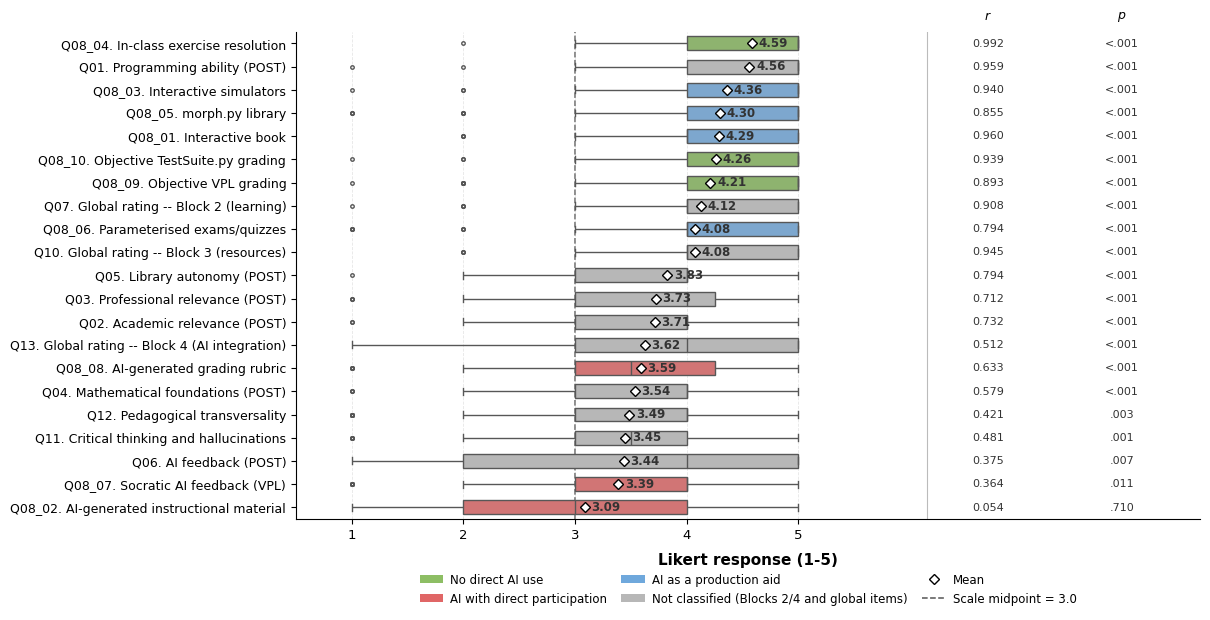

saved fig01_ranking21items.pdf


In [13]:
order = df21["label"].tolist()
ROLE_COLOR = {"none": "#8DBE64", "aid": "#6FA8DC", "direct": "#E06666", "unclassified": "#B7B7B7"}
ROLE_LEGEND = {"none": "No direct AI use", "aid": "AI as a production aid",
               "direct": "AI with direct participation",
               "unclassified": "Not classified (Blocks 2/4 and global items)"}

long_rows = []
for _, row in df21.iterrows():
    resp = pd.to_numeric(pos[row["item"]], errors="coerce").dropna()
    long_rows.append(pd.DataFrame({"label": row["label"], "response": resp}))
data_long = pd.concat(long_rows, ignore_index=True)
data_long["label"] = pd.Categorical(data_long["label"], categories=order, ordered=True)

palette = {row["label"]: ROLE_COLOR[row["role"]] for _, row in df21.iterrows()}

fig, ax = plt.subplots(figsize=(12.2, 6.3))
sns.boxplot(data=data_long, y="label", x="response", order=order, hue="label",
            palette=palette, legend=False, showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 5, "zorder": 10},
            width=0.6, linewidth=1.0, fliersize=2.5, ax=ax)
ax.axvline(x=VALOR_NEUTRO, color="#555555", linestyle="--", linewidth=1.1, alpha=0.85, zorder=1)

for i, (_, row) in enumerate(df21.iterrows()):
    ax.text(row["mean"] + 0.06, i, f"{row['mean']:.2f}", color="#333333",
            fontsize=8.5, fontweight="bold", va="center", ha="left", zorder=12)

COL_R, COL_P = 6.7, 7.9
ax.axvline(x=6.15, color="#BBBBBB", linestyle="-", linewidth=0.8, zorder=1)
ax.text(COL_R, -1.15, "$r$", fontsize=9, fontweight="bold", ha="center", va="center")
ax.text(COL_P, -1.15, "$p$", fontsize=9, fontweight="bold", ha="center", va="center")
for i, (_, row) in enumerate(df21.iterrows()):
    ax.text(COL_R, i, f"{row['r']:.3f}", color="#333333", fontsize=8, va="center", ha="center", zorder=12)
    ax.text(COL_P, i, format_p(row["p"]), color="#333333", fontsize=8, va="center", ha="center", zorder=12)

ax.set_xlim(0.5, 8.6)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Likert response (1-5)", fontsize=11, fontweight="bold", labelpad=8)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9.5)
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.30)
ax.grid(axis="y", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=ROLE_COLOR[r], edgecolor="none", label=ROLE_LEGEND[r])
           for r in ["none", "direct", "aid", "unclassified"]]
handles += [mlines.Line2D([], [], color="white", marker="D", markerfacecolor="white",
                          markeredgecolor="black", markersize=5, label="Mean"),
            mlines.Line2D([], [], color="#555555", linestyle="--", linewidth=1.1,
                          label="Scale midpoint = 3.0")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=3,
          frameon=False, fontsize=8.5, columnspacing=1.2, handletextpad=0.6)

plt.tight_layout()
fig.savefig("fig01_ranking21items.pdf", bbox_inches="tight")
plt.show()
print("saved fig01_ranking21items.pdf")


## 8. Academic outcomes (context only, not recomputed here)

Final grades come from institutional records (Moodle/Sigaa exports)
that contain students' real names and are **not** part of the
released dataset. The aggregate percentages below are reproduced
verbatim from the manuscript for reference; they are not derived from
any file in this notebook.

| Section | A grade | Pass rate |
|---|---|---|
| A | 40.9% | 75.0% |
| B | 58.1% | 86.0% |
| C | 54.5% | 81.8% |

Overall: 79 of 98 enrolled students passed (80.6%); 104 PRE and 80
POST respondents, with the enrolment total (98) lower than the PRE
count owing to withdrawals in the course's first two weeks.
